<a href="https://colab.research.google.com/github/bbcndoro/bigData/blob/kris/finalgtk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/RuangGTK_Project"

folders = [
    "01_raw",
    "02_preprocessed",
    "03_models/nb",
    "03_models/svm",
    "03_models/bert",
    "04_metrics/fold_results",
    "04_metrics/roc",
    "04_metrics/confusion_matrix",
    "05_statistical_test",
    "06_infografis",
    "07_error_analysis"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

print("Struktur folder berhasil dibuat.")

Struktur folder berhasil dibuat.


In [ ]:
# install package
!pip install google-play-scraper
!pip install Sastrawi
!pip install tqdm
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.9 MB/s eta 0:00:00


In [ ]:
# scrapping data di google play store
from google_play_scraper import reviews, Sort
import pandas as pd
from tqdm import tqdm

app_id = "id.belajar.app"  # ID aplikasi Ruang GTK

all_reviews = []
count = 0
batch_size = 200
continuation_token = None

while count < 10000:
    result, continuation_token = reviews(
        app_id,
        lang='id',
        country='id',
        sort=Sort.NEWEST,
        count=batch_size,
        continuation_token=continuation_token
    )

    all_reviews.extend(result)
    count = len(all_reviews)
    print("Total terkumpul:", count)

    if continuation_token is None:
        break

df = pd.DataFrame(all_reviews)
df = df[['content', 'score', 'at', 'thumbsUpCount']]

print("Total final:", len(df))

# simpan raw data
raw_path = os.path.join(BASE_DIR, "01_raw/ruanggtk_raw.csv")
df.to_csv(raw_path, index=False)
print("Raw data disimpan.")

Total terkumpul: 200
Total terkumpul: 400
Total terkumpul: 600
Total terkumpul: 800
Total terkumpul: 1000
Total terkumpul: 1200
Total terkumpul: 1400
Total terkumpul: 1600
Total terkumpul: 1800
Total terkumpul: 2000
Total terkumpul: 2200
Total terkumpul: 2400
Total terkumpul: 2600
Total terkumpul: 2800
Total terkumpul: 3000
Total terkumpul: 3200
Total terkumpul: 3400
Total terkumpul: 3600
Total terkumpul: 3800
Total terkumpul: 4000
Total terkumpul: 4200
Total terkumpul: 4400
Total terkumpul: 4600
Total terkumpul: 4800
Total terkumpul: 5000
Total terkumpul: 5200
Total terkumpul: 5400
Total terkumpul: 5600
Total terkumpul: 5800
Total terkumpul: 6000
Total terkumpul: 6200
Total terkumpul: 6400
Total terkumpul: 6600
Total terkumpul: 6800
Total terkumpul: 7000
Total terkumpul: 7200
Total terkumpul: 7400
Total terkumpul: 7600
Total terkumpul: 7800
Total terkumpul: 8000
Total terkumpul: 8200
Total terkumpul: 8400
Total terkumpul: 8600
Total terkumpul: 8800
Total terkumpul: 9000
Total terkumpu

In [ ]:
def labeling(score):
    if score >= 4:
        return "positif"
    elif score == 3:
        return "netral"
    else:
        return "negatif"

df['label'] = df['score'].apply(labeling)
df.head()

,content,score,at,thumbsUpCount,label
0,bagus,5,2026-02-24 15:23:01,0,positif
1,sangat mengesankan,5,2026-02-24 13:46:58,0,positif
2,sangat membantu,4,2026-02-24 03:16:06,0,positif
3,luar biasa,5,2026-02-24 01:16:53,0,positif
4,sangat bagus,5,2026-02-23 05:48:50,0,positif


In [ ]:
# Pre preprosesing
import re
import string
import pandas as pd
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from tqdm import tqdm

# Membuat objek stopword remover dari Sastrawi
factory = StopWordRemoverFactory()

# Mengambil daftar stopword Bahasa Indonesia
stopwords = set(factory.get_stop_words())



In [ ]:
def preprocess_text(text):
    """
    Fungsi preprocessing teks untuk analisis sentimen.
    Tahapan:
    1. Case folding
    2. Hapus URL
    3. Hapus angka
    4. Hapus tanda baca
    5. Stopword removal (Sastrawi)
    """

    # Pastikan teks berbentuk string
    text = str(text)

    # ===============================
    # 1 CASE FOLDING
    # Mengubah seluruh huruf menjadi huruf kecil
    # ===============================
    text = text.lower()

    # ===============================
    # 2️ HAPUS URL
    # Menghapus link seperti http://, https://, www.
    # ===============================
    text = re.sub(r'http\S+|www\S+', '', text)

    # ===============================
    # 3️ HAPUS ANGKA
    # Menghapus semua karakter numerik (0-9)
    # ===============================
    text = re.sub(r'\d+', '', text)

    # ===============================
    # 4️ HAPUS TANDA BACA
    # Menghapus simbol seperti ! ? . , dll
    # ===============================
    text = text.translate(str.maketrans('', '', string.punctuation))

    # ===============================
    # 5️ STOPWORD REMOVAL (SASTRAWI)
    # Menghapus kata umum yang tidak memiliki makna sentimen
    # ===============================
    tokens = text.split()  # Tokenisasi sederhana berdasarkan spasi
    filtered_tokens = [word for word in tokens if word not in stopwords]
    text = " ".join(filtered_tokens)

    # ===============================
    # HAPUS SPASI BERLEBIH
    # ===============================
    text = re.sub(r'\s+', ' ', text).strip()

    return text



from tqdm import tqdm
tqdm.pandas()  # Menampilkan progress bar

df['clean'] = df['content'].progress_apply(preprocess_text)
# Menghapus baris dengan hasil preprocessing kosong
df = df[df['clean'].str.strip() != ""]

# Reset index agar rapi
df.reset_index(drop=True, inplace=True)

print("Jumlah data setelah preprocessing:", len(df))

save_path = BASE_DIR + "/02_preprocessed/ruanggtk_clean.csv"
df.to_csv(save_path, index=False)

print("Data preprocessing berhasil disimpan.")

# Simpan dataset khusus modeling
modeling_df = df[['clean', 'label']]

modeling_df.to_csv(
    os.path.join(BASE_DIR, "02_preprocessed/ruanggtk_modeling.csv"),
    index=False
)

print("Dataset clean + label untuk modeling berhasil disimpan.")

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

df[['clean','label','label_enc']].to_csv(
    os.path.join(BASE_DIR, "02_preprocessed/ruanggtk_labeled_encoded.csv"),
    index=False
)

100%|██████████| 10000/10000 [00:00<00:00, 38042.06it/s]


Jumlah data setelah preprocessing: 9798
Data preprocessing berhasil disimpan.
Dataset clean + label untuk modeling berhasil disimpan.


Distribusi Label:


,Jumlah,Persentase (%)
label,,
positif,9081,92.68
netral,226,2.31
negatif,491,5.01


Tabel distribusi berhasil disimpan di 04_metrics.


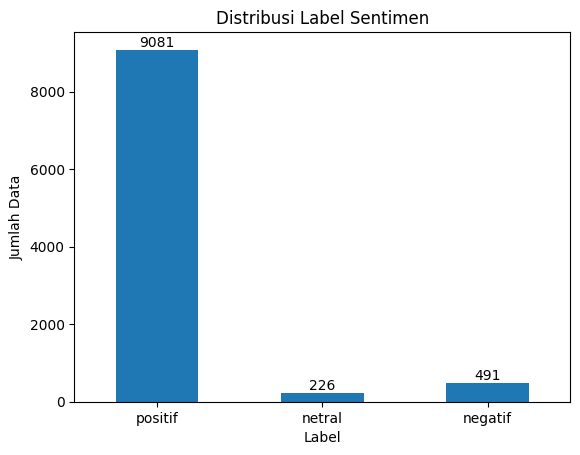

Grafik distribusi berhasil disimpan di 06_infografis.


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# FUNGSI PELABELAN
# =========================
def labeling(score):
    if score >= 4:
        return "positif"
    elif score == 3:
        return "netral"
    else:
        return "negatif"

# Terapkan pelabelan
df['label'] = df['score'].apply(labeling)

# =========================
# BUAT TABEL DISTRIBUSI
# =========================
label_counts = df['label'].value_counts()
label_percentage = df['label'].value_counts(normalize=True) * 100

distribution_table = pd.DataFrame({
    'Jumlah': label_counts,
    'Persentase (%)': label_percentage.round(2)
})

# Urutkan agar konsisten
distribution_table = distribution_table.reindex(['positif', 'netral', 'negatif'])

# Tampilkan tabel
print("Distribusi Label:")
display(distribution_table)

# Simpan tabel ke folder 04_metrics
metrics_path = os.path.join(BASE_DIR, "04_metrics/label_distribution.csv")
distribution_table.to_csv(metrics_path)

print("Tabel distribusi berhasil disimpan di 04_metrics.")

# =========================
# BUAT GRAFIK DENGAN ANOTASI
# =========================
plt.figure()

ordered_counts = df['label'].value_counts().reindex(['positif', 'netral', 'negatif'])
ax = ordered_counts.plot(kind='bar')

plt.title("Distribusi Label Sentimen")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)

# Tambahkan anotasi angka di atas batang
for i, value in enumerate(ordered_counts):
    plt.text(i, value + 0.5, str(value), ha='center', va='bottom')

# Simpan grafik ke folder 06_infografis
graph_path = os.path.join(BASE_DIR, "06_infografis/label_distribution.png")
plt.savefig(graph_path, bbox_inches='tight')

plt.show()

print("Grafik distribusi berhasil disimpan di 06_infografis.")

In [ ]:
# =========================================================
# INSTALL
# =========================================================
!pip install transformers datasets torch -q

# =========================================================
# IMPORT
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import joblib

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import *

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import Dataset

# =========================================================
# SET SEED
# =========================================================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# =========================================================
# LABEL ENCODING
# =========================================================
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])

X = df["clean"]
y = df["label_enc"]

# =========================================================
# =========================================================
# PART 1 — NB & SVM (5-FOLD CV)
# =========================================================
# =========================================================

print("\n🔹 5-Fold Evaluation (NB & SVM)")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

nb_scores = []
svm_scores = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

    print(f"\n===== FOLD {fold} =====")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # NB
    nb_model = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000)),
        ("clf", MultinomialNB())
    ])
    nb_model.fit(X_train, y_train)
    nb_pred = nb_model.predict(X_test)

    f1_nb = f1_score(y_test, nb_pred, average="weighted")
    nb_scores.append(f1_nb)

    # SVM
    svm_model = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000)),
        ("clf", LinearSVC())
    ])
    svm_model.fit(X_train, y_train)
    svm_pred = svm_model.predict(X_test)

    f1_svm = f1_score(y_test, svm_pred, average="weighted")
    svm_scores.append(f1_svm)

print("\n===== FINAL 5-FOLD RESULT =====")
print("NB Mean F1:", np.mean(nb_scores), "±", np.std(nb_scores))
print("SVM Mean F1:", np.mean(svm_scores), "±", np.std(svm_scores))

# =========================================================
# =========================================================
# PART 2 — INDOBERT (80-10-10 HOLDOUT)
# =========================================================
# =========================================================

print("\n🔹 IndoBERT 80-10-10 Evaluation")

# 80 train_temp, 20 test
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

# Split train_temp → train & val (10% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp,
    test_size=0.125,
    stratify=y_train_temp,
    random_state=SEED
)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

# =========================================================
# LOAD MODEL
# =========================================================

model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(model_name)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(le.classes_)
)

# =========================================================
# DATASET
# =========================================================

train_dataset = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

val_dataset = Dataset.from_dict({
    "text": X_val.tolist(),
    "label": y_val.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
val_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])
test_dataset.set_format(type="torch", columns=["input_ids","attention_mask","label"])

# =========================================================
# TRAINING ARGUMENTS
# =========================================================

training_args = TrainingArguments(
    output_dir="./bert_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    fp16=True,
    logging_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

# =========================================================
# FINAL TEST EVALUATION
# =========================================================

preds = trainer.predict(test_dataset).predictions
bert_pred = np.argmax(preds, axis=1)

acc = accuracy_score(y_test, bert_pred)
prec = precision_score(y_test, bert_pred, average="weighted")
rec = recall_score(y_test, bert_pred, average="weighted")
f1 = f1_score(y_test, bert_pred, average="weighted")

print("\n===== INDOBERT TEST RESULT =====")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1       :", f1)

# Save model
trainer.save_model("./best_indobert_model")

# =========================================================
# FINAL COMPARISON TABLE
# =========================================================

result_df = pd.DataFrame({
    "Model": ["NB (5F)", "SVM (5F)", "IndoBERT (Test)"],
    "F1": [
        np.mean(nb_scores),
        np.mean(svm_scores),
        f1
    ]
})

display(result_df)


🔹 5-Fold Evaluation (NB & SVM)

===== FOLD 1 =====

===== FOLD 2 =====

===== FOLD 3 =====

===== FOLD 4 =====

===== FOLD 5 =====

===== FINAL 5-FOLD RESULT =====
NB Mean F1: 0.8955554175174317 ± 0.00237773982642713
SVM Mean F1: 0.9118131290911362 ± 0.003876556285788554

🔹 IndoBERT 80-10-10 Evaluation
Train: 6858
Val: 980
Test: 1960


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/980 [00:00<?, ? examples/s]

Map:   0%|          | 0/1960 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

def evaluate(name, y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted")
    rec = recall_score(y_true, y_pred, average="weighted")
    f1_w = f1_score(y_true, y_pred, average="weighted")
    cm = confusion_matrix(y_true, y_pred)

    # Confusion Matrix Plot
    plt.figure()
    plt.imshow(cm)
    plt.title(f"Confusion Matrix {name}")
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig(os.path.join(BASE_DIR, f"06_infografis/cm_{name}.png"))
    plt.close()

    print(f"\n{name} Results")
    print("Accuracy :", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall   :", round(rec,4))
    print("F1-score :", round(f1_w,4))

    return acc, prec, rec, f1_w

print("🔹 Evaluating...")

print("🔹 Evaluating Models...")

acc_nb, prec_nb, rec_nb, f1_nb = evaluate("NB", y_test, nb_pred)
acc_svm, prec_svm, rec_svm, f1_svm = evaluate("SVM", y_test, svm_pred)
acc_bert, prec_bert, rec_bert, f1_bert = evaluate("BERT", y_test, bert_pred)

# =========================================================
# ROC MULTICLASS
# =========================================================

from sklearn.preprocessing import label_binarize

print("🔹 ROC Curve...")

n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

def plot_roc(model, name, logits=None):

    if logits is not None:
        y_score = logits
    else:
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)
        else:
            y_score = model.decision_function(X_test)

    plt.figure()
    auc_scores = []

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC={roc_auc:.3f})")

    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title(f"ROC Curve - {name}")

    plt.savefig(os.path.join(BASE_DIR, f"06_infografis/roc_{name}.png"))
    plt.close()

    return np.mean(auc_scores)

roc_nb = plot_roc(nb_model,"NB")
roc_svm = plot_roc(svm_model,"SVM")
roc_bert = plot_roc(None,"BERT",bert_logits)

# =========================================================
# BOOTSTRAP 95% CI
# =========================================================

def bootstrap_ci(y_true, y_pred, n=1000):

    scores=[]
    y_true=np.array(y_true)

    for _ in range(n):
        idx=np.random.choice(len(y_true),len(y_true),replace=True)
        score=f1_score(y_true[idx],y_pred[idx],average="weighted")
        scores.append(score)

    return np.mean(scores), np.percentile(scores,2.5), np.percentile(scores,97.5)

nb_mean,nb_low,nb_high=bootstrap_ci(y_test,nb_pred)
svm_mean,svm_low,svm_high=bootstrap_ci(y_test,svm_pred)
bert_mean,bert_low,bert_high=bootstrap_ci(y_test,bert_pred)

# =========================================================
# EFFECT SIZE (Cohen's d) - Paired Comparison
# =========================================================

def cohens_d_paired(a, b):
    diff = np.array(a) - np.array(b)
    return diff.mean() / diff.std(ddof=1)

nb_correct = (nb_pred == y_test).astype(int)
svm_correct = (svm_pred == y_test).astype(int)
bert_correct = (bert_pred == y_test).astype(int)

d_nb_svm = cohens_d_paired(nb_correct, svm_correct)
d_nb_bert = cohens_d_paired(nb_correct, bert_correct)
d_svm_bert = cohens_d_paired(svm_correct, bert_correct)

effect_table = pd.DataFrame({
    "Comparison": [
        "NB vs SVM",
        "NB vs BERT",
        "SVM vs BERT"
    ],
    "Cohens_d": [
        d_nb_svm,
        d_nb_bert,
        d_svm_bert
    ]
})

effect_table.to_csv(
    os.path.join(BASE_DIR,"05_statistical_test/effect_size.csv"),
    index=False
)

# =========================================================
# SUMMARY TABLE (FULL METRICS)
# =========================================================

stat_table=pd.DataFrame({
    "Model":["NB","SVM","BERT"],
    "Accuracy":[acc_nb,acc_svm,acc_bert],
    "Precision":[prec_nb,prec_svm,prec_bert],
    "Recall":[rec_nb,rec_svm,rec_bert],
    "Mean F1":[nb_mean,svm_mean,bert_mean],
    "CI Lower":[nb_low,svm_low,bert_low],
    "CI Upper":[nb_high,svm_high,bert_high],
    "ROC-AUC":[roc_nb,roc_svm,roc_bert]
})

stat_table.to_csv(
    os.path.join(BASE_DIR,"05_statistical_test/stat_summary.csv"),
    index=False
)

display(stat_table)

# =========================================================
# BAR CHART
# =========================================================

plt.figure()

models=["NB","SVM","BERT"]
means=[nb_mean,svm_mean,bert_mean]

plt.bar(models,means)
plt.ylim(0,1)

for i,v in enumerate(means):
    plt.text(i,v+0.01,round(v,3),ha="center")

plt.title("Model Comparison (Mean Weighted F1)")
plt.savefig(os.path.join(BASE_DIR,"06_infografis/final_comparison.png"))
plt.close()

print("✅ EVALUATION SELESAI")